In [1]:
import numpy as np
import os, sys 
import re
import ROOT
ROOT.gStyle.SetOptStat(0)
import array
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import glob
import pandas as pd

import matplotlib.pyplot as plt
from linearization import linearization
import read_relcal
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
from ROOplot import ROOplot

Welcome to JupyROOT 6.28/10


In [2]:
def createFilter_EvtNum():

	ROOT.gInterpreter.Declare("""
	#include <vector>
	#include <algorithm>

	bool eventFilter(const double colEventNum, const std::vector<double>& targetEventNums) {
		bool eventMatch = std::find(targetEventNums.begin(), targetEventNums.end(), colEventNum) != targetEventNums.end();
		return eventMatch;
	}
	""")

createFilter_EvtNum()

In [12]:
def MaxArray():

	ROOT.gInterpreter.Declare("""
	double find_maximum(const ROOT::VecOps::RVec<double>& vec) {
        return *std::max_element(vec.begin(), vec.end());
}
	""")

MaxArray()

In [13]:
def MinArray():

	ROOT.gInterpreter.Declare("""
	double find_minimum(const ROOT::VecOps::RVec<double>& vec) {
        return *std::min_element(vec.begin(), vec.end());
}
	""")

MinArray()

In [4]:
fp = "/project/6049244/share/SimData/DMC_SNOLAB_HV/" ## this is the global file path the DMC data is saved in on compute canada

## Define the filepaths used
samples = {"L": "Ge71_Lshell_pos50V_V05-09",
           "K": "Ge71_Kshell_pos50V_V05-09"}
truth =   {"L": "/DMCOutput/*.root",
           "K": "/DMCOutput/*.root"}
proc =    {"L": "/Processed/Unmerged/*/*.root",
           "K": "/Processed/Unmerged/*/*.root"}

In [5]:
## Get the file names in these folders
RQfiles_K, RQfiles_L       = np.sort(glob.glob(fp+samples["K"]+proc["K"])), np.sort(glob.glob(fp+samples["L"]+proc["L"]))
truthfiles_K, truthfiles_L = np.sort(glob.glob(fp+samples["K"]+truth["K"])), np.sort(glob.glob(fp+samples["L"]+truth["L"]))

In [6]:
config_path = "/scratch/perry/processing/cdmsbats_config/UserSettings/BatRootSettings/analysis/"
config_sim = "DMCData.HV100mm_uni_triangle"
config_data = "configCUTEData.NxM.50VZ1Z30VZ6.V4.0.0"
relcal_path = {'sim':  config_path+config_sim,
               'data': config_path+config_data}

det     = {'sim': 1, 'data': 1}
trigdet = {'sim': 0, 'data': 1}

In [30]:
## load relevant RQs for simulation
df_K = CDataFrame("rqDir/zip"+str(det["sim"]), RQfiles_K, friends = [[x+":rqDir/eventTree" for x in RQfiles_K]])
    
## Apply some basic data quality filters and get the RQs you're interested in
df_K_filtered = df_K.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(trigdet["sim"])]) #, "PTOFamps>10.4e-6", "PTOFamps<11e-6"])

In [31]:
df_TES = CDataFrame('G4SimDir/g4dmcTES', truthfiles_K)

targetIDs = ROOT.std.vector("double")(df_K_filtered.AsNumpy(['EventTriggerID'])['EventTriggerID'])
df_TES_filtered = df_TES.Filter(f"eventFilter(EventNum,{targetIDs}) & (DataType==0)")

In [32]:
relcal = {
    '1': {'PFS1': 0.935,
 'PCS1': 1.002,
 'PDS1': 0.998,
 'PBS1': 1.076,
 'PES1': 1.018,
 'PAS1': 1.14,
 'PFS2': 0.895,
 'PCS2': 0.931,
 'PBS2': 1.008,
 'PES2': 0.946,
 'PDS2': 0.992,
 'PAS2': 1.059}
}

In [33]:
df_TES_filtered = df_TES_filtered.Define('MinHeight', 'find_minimum(Trace)')
df_TES_filtered = df_TES_filtered.Define('MaxHeight', 'find_maximum(Trace)')

In [34]:
TES = df_TES_filtered.AsNumpy(['EventNum', 'ChanName', 'MinHeight', 'MaxHeight'])

In [35]:
TES['Amp'] = np.array([(TES['MaxHeight'][i] - TES['MinHeight'][i])*relcal['1'][TES['ChanName'][i]] for i in range(len(TES['EventNum']))])

In [36]:
PFsum = TES['Amp'][TES['ChanName'] == 'PFS1'] + TES['Amp'][TES['ChanName'] == 'PFS2']
PAsum = TES['Amp'][TES['ChanName'] == 'PAS1'] + TES['Amp'][TES['ChanName'] == 'PAS2']
PT = np.array([sum(TES['Amp'][TES['EventNum'] == event]) for event in np.unique(TES['EventNum'])])

In [37]:
RadialPar = (PFsum - PAsum) / PT

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


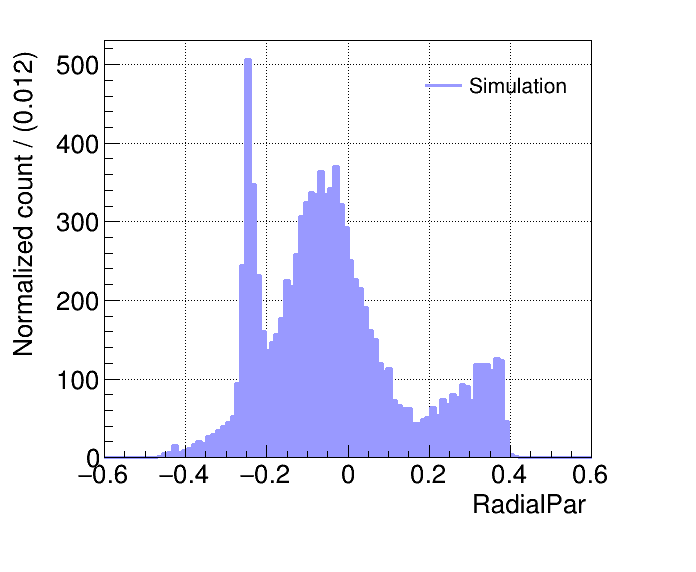

In [38]:
bins_start, bins_end, nbins = -0.6, 0.6, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="RadialPar", _ylabel="Normalized count / (" + str(binwidth) + ")")

hist.createHist(RadialPar, bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-9, fillstyle=1001, label="Simulation")

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()